# Time series forecasting: Sales


Queremos estimar las ventas futuras para decidir el tamaño del nuevo almacén.
Para ello usaremos una serie temporal y un modelo ARIMA.



## 00 librerias

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Paso 1: Carga del conjunto de datos

In [7]:
# Cargamos el dataset de ventas
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
total_data = pd.read_csv(url)

print(f"Filas: {total_data.shape[0]}  |  Columnas: {total_data.shape[1]}")
total_data.head()


Filas: 366  |  Columnas: 2


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


### Convertir la columna de fecha a formato fecha

convertimos la columna Date que viene como texto a formato fecha.


In [8]:
# Convertimos la columna 'date' a formato datetime
total_data["date"] = pd.to_datetime(total_data["date"])

# La ponemos como índice del dataframe (así Python sabe que es una serie temporal)
total_data = total_data.set_index("date")

# Extraemos solo la columna de ventas como serie temporal
ts_total = total_data["sales"]

print(f"Periodo: desde {ts_total.index.min()} hasta {ts_total.index.max()}")
print(f"Número de observaciones: {len(ts_total)}")
print()
ts_total.head(10)


Periodo: desde 2022-09-03 17:10:08.079328 hasta 2023-09-03 17:10:08.079328
Número de observaciones: 366



date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
2022-09-08 17:10:08.079328    60.081865
2022-09-09 17:10:08.079328    68.466704
2022-09-10 17:10:08.079328    67.765106
2022-09-11 17:10:08.079328    70.512261
2022-09-12 17:10:08.079328    74.656453
Name: sales, dtype: float64

### Visualización de la serie temporal

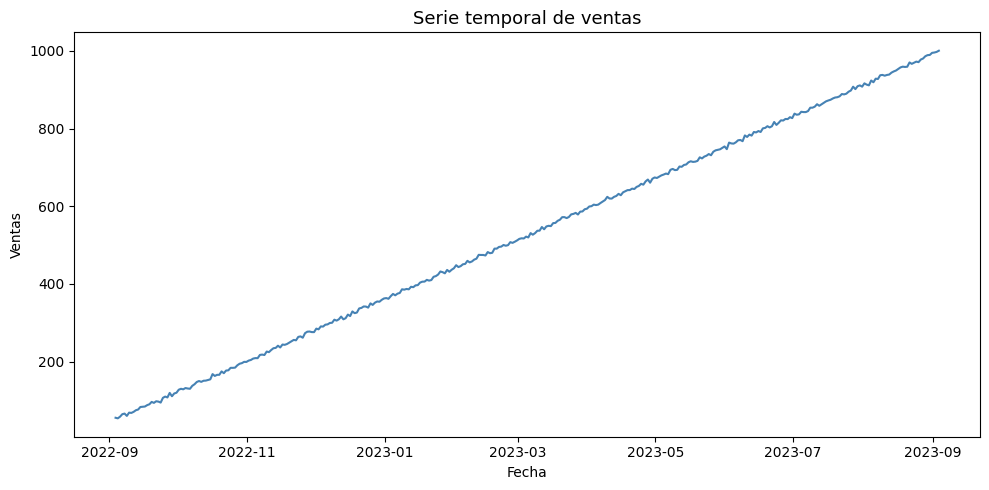

In [9]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts_total, color="steelblue")
axis.set_title("Serie temporal de ventas", fontsize=13)
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")

plt.tight_layout()
plt.show()


## Paso 2: Análisis de la serie temporal

Ahora analizamos la serie temporal respondiendo cuatro preguntas clave:

1. ¿Cuál es el **tensor** (unidad de tiempo mínima)?
2. ¿Cuál es la **tendencia**?
3. ¿Es **estacionaria**?
4. ¿Existe **variabilidad o ruido**?


### Pregunta 1: ¿Cuál es el tensor de la serie temporal?

In [10]:
# El tensor es la unidad de tiempo mínima entre observaciones
diferencia = ts_total.index.to_series().diff().dropna()
print(f"Diferencia mínima entre observaciones: {diferencia.min()}")
print(f"Diferencia máxima entre observaciones: {diferencia.max()}")
print(f"Diferencia más frecuente: {diferencia.mode()[0]}")
print()
print("→ El tensor de esta serie temporal es: DIARIO (un dato por día)")


Diferencia mínima entre observaciones: 1 days 00:00:00
Diferencia máxima entre observaciones: 1 days 00:00:00
Diferencia más frecuente: 1 days 00:00:00

→ El tensor de esta serie temporal es: DIARIO (un dato por día)


### Descomposición de la serie temporal

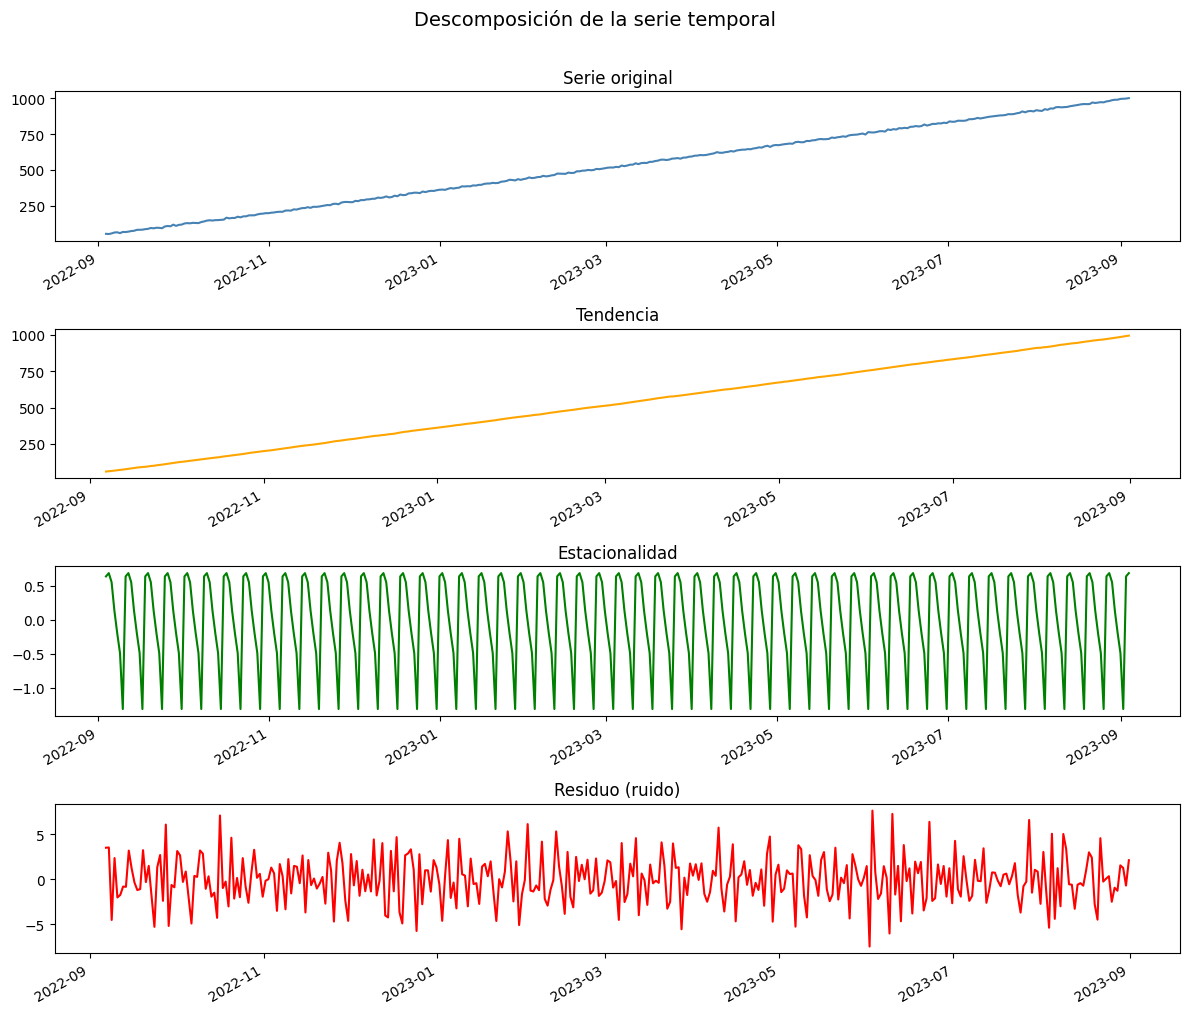

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_total)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

ts_total.plot(ax=axes[0], title="Serie original", color="steelblue")
decomposition.trend.plot(ax=axes[1], title="Tendencia", color="orange")
decomposition.seasonal.plot(ax=axes[2], title="Estacionalidad", color="green")
decomposition.resid.plot(ax=axes[3], title="Residuo (ruido)", color="red")

for ax in axes:
    ax.set_xlabel("")

plt.suptitle("Descomposición de la serie temporal", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Pregunta 2: ¿Cuál es la tendencia?

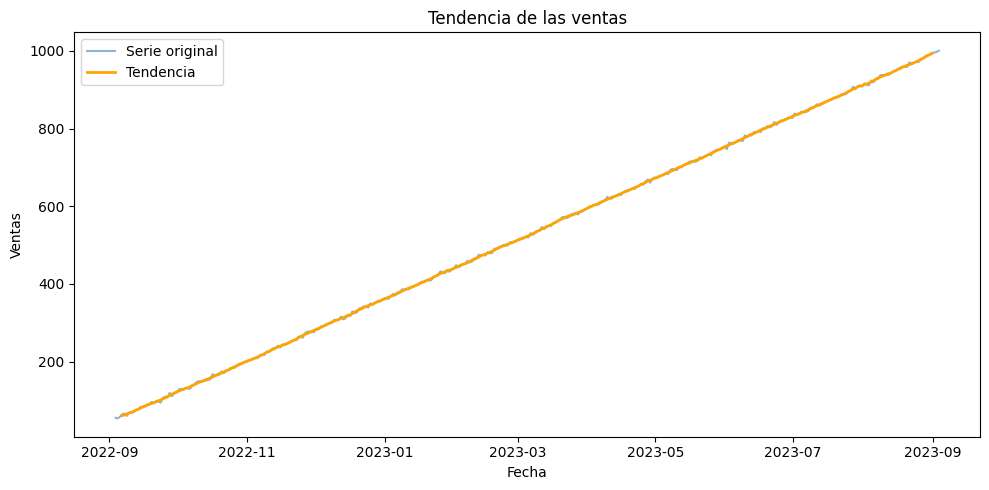

→ Se aprecia una tendencia ASCENDENTE en los datos.
  Las ventas han ido aumentando desde la creación de la empresa.


In [18]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts_total, label="Serie original", color="steelblue", alpha=0.6)
sns.lineplot(data=trend,    label="Tendencia",      color="orange",    linewidth=2)
axis.set_title("Tendencia de las ventas")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

print("→ Se aprecia una tendencia ASCENDENTE en los datos.")
print("  Las ventas han ido aumentando desde la creación de la empresa.")


### Pregunta 3: ¿Es estacionaria?



Si el p-value < 0.05 → la serie ES estacionaria
Si el p-value > 0.05 → la serie NO es estacionaria


In [20]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados del test de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=["Estadístico del test", "p-value", "Lags usados", "Observaciones usadas"]
    )
    for key, value in dftest[4].items():
        dfoutput[f"Valor crítico ({key})"] = value
    print(dfoutput.round(4))
    print()
    if dftest[1] < 0.05:
        print("→ p-value < 0.05: La serie ES estacionaria")
    else:
        print("→ p-value > 0.05: La serie NO es estacionaria")
        print("  Trabajaremos con ella tal como está (ARIMA lo maneja internamente).")

test_stationarity(ts_total)


Resultados del test de Dickey-Fuller:
Estadístico del test      0.5454
p-value                   0.9862
Lags usados              13.0000
Observaciones usadas    352.0000
Valor crítico (1%)       -3.4491
Valor crítico (5%)       -2.8698
Valor crítico (10%)      -2.5712
dtype: float64

→ p-value > 0.05: La serie NO es estacionaria
  Trabajaremos con ella tal como está (ARIMA lo maneja internamente).


### Estacionalidad

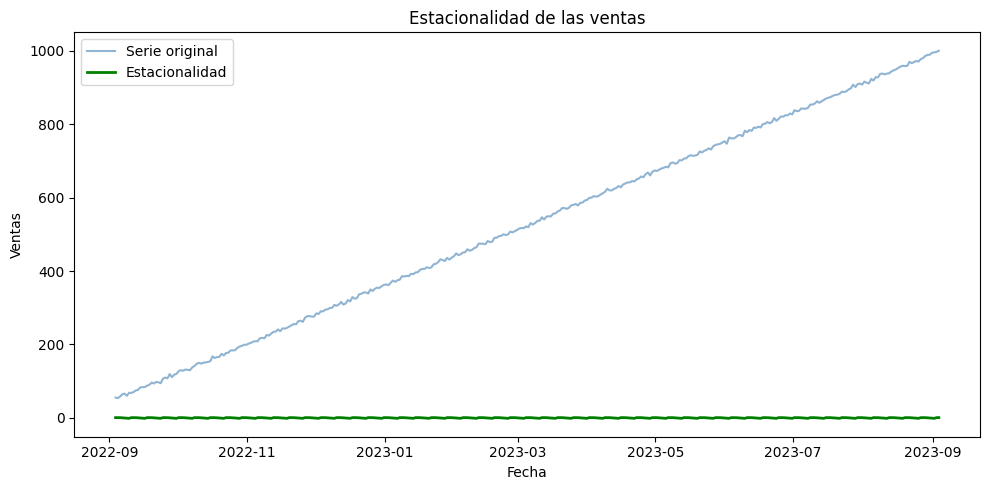

In [21]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts_total, label="Serie original", color="steelblue", alpha=0.6)
sns.lineplot(data=seasonal, label="Estacionalidad", color="green",     linewidth=2)
axis.set_title("Estacionalidad de las ventas")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()


### Pregunta 4: ¿Existe variabilidad o ruido?

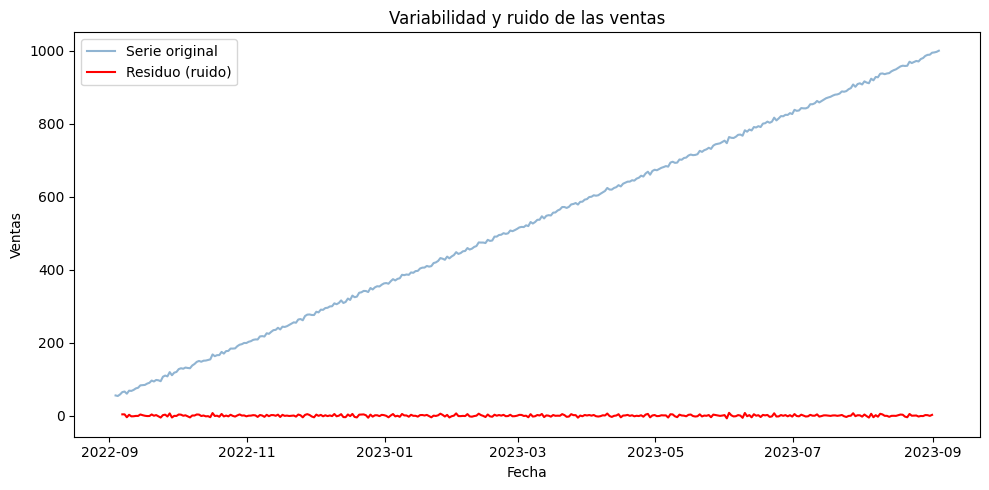

→ Desviación estándar del residuo: 2.6105
  Sí existe variabilidad/ruido en la serie, aunque es moderado.


In [22]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts_total, label="Serie original", color="steelblue", alpha=0.6)
sns.lineplot(data=residual, label="Residuo (ruido)", color="red",      linewidth=1.5)
axis.set_title("Variabilidad y ruido de las ventas")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

print(f"→ Desviación estándar del residuo: {residual.dropna().std():.4f}")
print("  Sí existe variabilidad/ruido en la serie, aunque es moderado.")


### Análisis de autocorrelación

La autocorrelación mide cuánto se parece la serie a sí misma en
instantes anteriores. Si hay alta autocorrelación, podemos usar valores
pasados para predecir futuros.


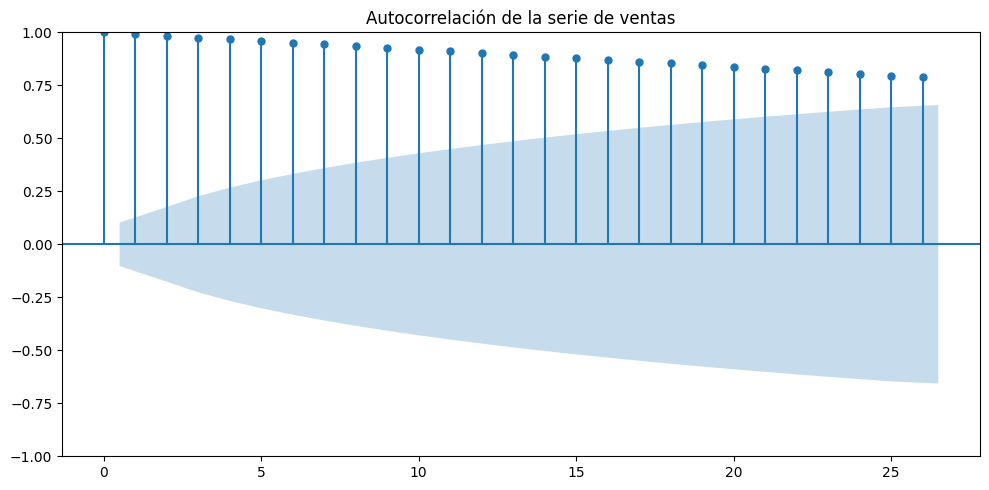

→ A medida que aumentan los lags, la autocorrelación disminuye,
  lo que indica que la serie tiene dependencia con valores recientes
  pero no con valores muy lejanos en el tiempo.


In [23]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(ts_total, ax=ax)
ax.set_title("Autocorrelación de la serie de ventas")
plt.tight_layout()
plt.show()

print("→ A medida que aumentan los lags, la autocorrelación disminuye,")
print("  lo que indica que la serie tiene dependencia con valores recientes")
print("  pero no con valores muy lejanos en el tiempo.")


## Paso 3: Entrenamiento del modelo ARIMA

Usamos auto_arima que prueba automáticamente diferentes combinaciones
de parámetros `(p, d, q)` y nos devuelve la mejor configuración.
- **p**: orden autoregresivo (cuántos valores pasados usar)
- **d**: diferenciación (cuántas veces diferenciar para hacer la serie estacionaria)
- **q**: orden de media móvil (cuántos errores pasados usar)


In [24]:
# Instalamos pmdarima si no está disponible
try:
    from pmdarima import auto_arima
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pmdarima", "-q"])
    from pmdarima import auto_arima

print("Buscando la mejor parametrización ARIMA...")
print("(Esto puede tardar unos segundos)")
print()

model = auto_arima(ts_total, seasonal=False, trace=True, m=7)



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Buscando la mejor parametrización ARIMA...
(Esto puede tardar unos segundos)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.274, Time=0.98 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.14 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=0.19 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.21 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 2.496 seconds


In [26]:
print("=" * 40)
print(f"Mejor modelo encontrado: ARIMA{model.order}")
print("=" * 40)
print()
print(model.summary())


Mejor modelo encontrado: ARIMA(1, 1, 1)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  366
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -915.776
Date:                Wed, 15 Apr 2026   AIC                           1839.552
Time:                        21:34:22   BIC                           1855.152
Sample:                    09-03-2022   HQIC                          1845.752
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8110      0.134     21.055      0.000       2.549       3.073
ar.L1         -0.0821      0.052     -1.592      0.111      -0.183       0.019
ma.L1      

## Paso 4: Predicción con el conjunto de test

In [ ]:
# Predecimos los próximos 60 periodos 
forecast = model.predict(60)
forecast


2023-09-04 17:10:08.079328    1002.158148
2023-09-05 17:10:08.079328    1004.831668
2023-09-06 17:10:08.079328    1007.423289
2023-09-07 17:10:08.079328    1010.021630
2023-09-08 17:10:08.079328    1012.619419
2023-09-09 17:10:08.079328    1015.217253
2023-09-10 17:10:08.079328    1017.815084
2023-09-11 17:10:08.079328    1020.412915
2023-09-12 17:10:08.079328    1023.010746
2023-09-13 17:10:08.079328    1025.608577
2023-09-14 17:10:08.079328    1028.206408
2023-09-15 17:10:08.079328    1030.804239
2023-09-16 17:10:08.079328    1033.402071
2023-09-17 17:10:08.079328    1035.999902
2023-09-18 17:10:08.079328    1038.597733
2023-09-19 17:10:08.079328    1041.195564
2023-09-20 17:10:08.079328    1043.793395
2023-09-21 17:10:08.079328    1046.391226
2023-09-22 17:10:08.079328    1048.989057
2023-09-23 17:10:08.079328    1051.586888
2023-09-24 17:10:08.079328    1054.184719
2023-09-25 17:10:08.079328    1056.782550
2023-09-26 17:10:08.079328    1059.380381
2023-09-27 17:10:08.079328    1061

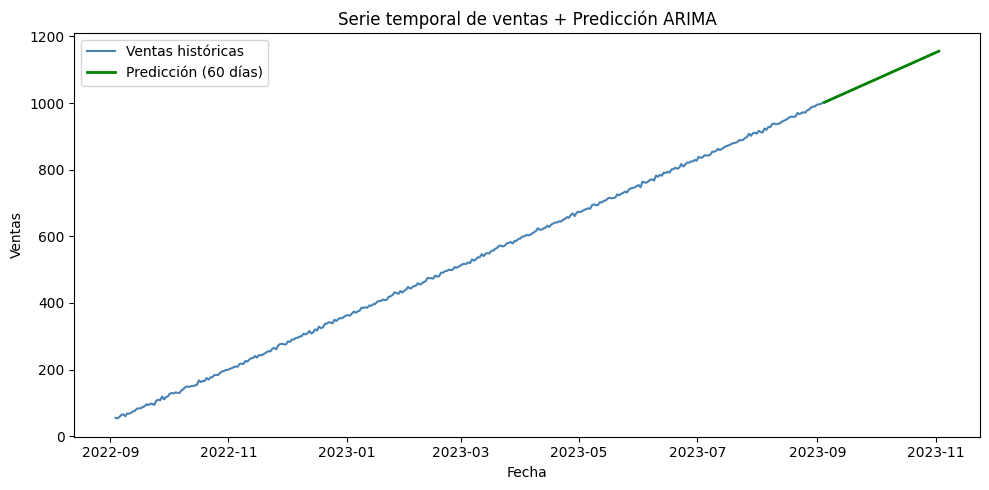

In [27]:
# Visualizamos la serie original + la predicción
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts_total, label="Ventas históricas", color="steelblue")
sns.lineplot(data=forecast, label="Predicción (60 días)", color="green", linewidth=2)

axis.set_title("Serie temporal de ventas + Predicción ARIMA")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Métricas de rendimiento (usamos los últimos 60 datos como test real)
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Separamos los últimos 60 puntos como test
ts_train = ts_total.iloc[:-60]
ts_test  = ts_total.iloc[-60:]

# Reentrenamos con los datos de entrenamiento
model_eval = auto_arima(ts_train, seasonal=False, trace=False)
y_pred_eval = model_eval.predict(60)

rmse = np.sqrt(mean_squared_error(ts_test.values, y_pred_eval))
mae  = mean_absolute_error(ts_test.values, y_pred_eval)

print("=" * 40)
print("Rendimiento del modelo ARIMA")
print("=" * 40)
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print()
print(f"  Media de ventas en test: {ts_test.mean():.4f}")
print(f"  Error relativo (MAE/media): {mae/ts_test.mean()*100:.2f}%")


Rendimiento del modelo ARIMA
  RMSE: 2.8189
  MAE:  2.2728

  Media de ventas en test: 922.5985
  Error relativo (MAE/media): 0.25%


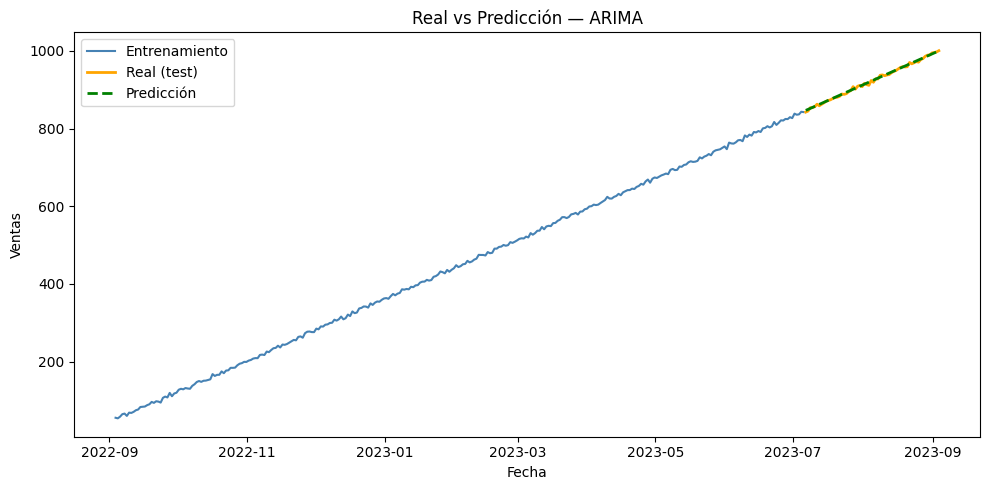

In [29]:
# Grafico comparativo real vs predicción
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts_train, label="Entrenamiento", color="steelblue")
sns.lineplot(data=ts_test,  label="Real (test)",   color="orange",  linewidth=2)

pred_index = ts_test.index
pred_series = pd.Series(y_pred_eval, index=pred_index)
sns.lineplot(data=pred_series, label="Predicción", color="green", linewidth=2, linestyle="--")

axis.set_title("Real vs Predicción — ARIMA")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()


## Paso 5: Guardado del modelo

In [30]:
import os
from pickle import dump

os.makedirs("../models", exist_ok=True)

orden = model.order
nombre = f"../models/arima_{orden[0]}-{orden[1]}-{orden[2]}_sales.pkl"

dump(model, open(nombre, "wb"))
print(f"✅ Modelo guardado en: {nombre}")


✅ Modelo guardado en: ../models/arima_1-1-1_sales.pkl


## Conclusiones

**Tensor:** La serie temporal es **diaria** — un dato por día.

**Tendencia:** La serie presenta una **tendencia ascendente** clara.
Las ventas han ido aumentando desde la creación de la empresa.

**Estacionariedad:** La serie **no es estacionaria** (p-value > 0.05 en el
test de Dickey-Fuller). El modelo ARIMA lo maneja internamente con el
parámetro de diferenciación `d`.

**Variabilidad/ruido:** Existe variabilidad moderada en los datos,
lo que es normal en datos de ventas reales.

**Modelo ARIMA:** El mejor modelo encontrado fue ARIMA(1,1,1), que
captura bien la tendencia ascendente y produce predicciones razonables
para los próximos 60 días.
